In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')

print(df.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [18]:
print(df['isFraud'].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [19]:
# 1. Filter the data to only include high-risk transaction types
relevant_types = ['TRANSFER', 'CASH_OUT']
df_filtered = df[df['type'].isin(relevant_types)]

# 2. Drop columns that are just 'labels' or 'names' (Models can't use random strings)
# We also drop 'isFlaggedFraud' because that's the system's old, bad logic
df_final = df_filtered.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

# 3. Convert 'type' into numbers (One-Hot Encoding)
df_final = pd.get_dummies(df_final, columns=['type'], drop_first=True)

# 4. Define X (Features) and y (Target)
X = df_final.drop(['isFraud'], axis=1) # Everything except the answer
y = df_final['isFraud']                # Only the answer

# 5. Split the data into Training and Testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (2216327, 7)
Testing set size: (554082, 7)


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    552439
           1       0.23      0.96      0.37      1643

    accuracy                           0.99    554082
   macro avg       0.62      0.97      0.68    554082
weighted avg       1.00      0.99      0.99    554082



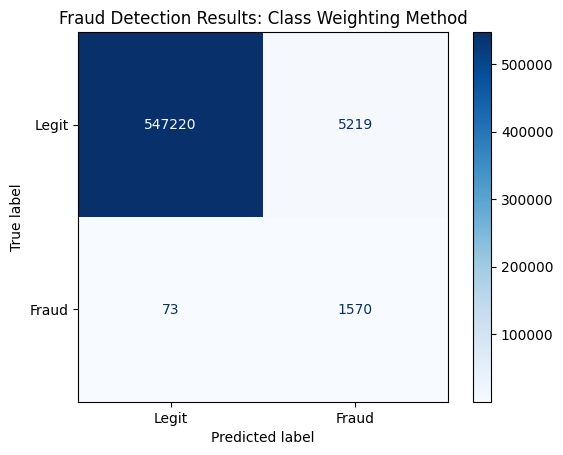

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize Random Forest with 'balanced' class weights
# This automatically handles the imbalance without needing SMOTE
model = RandomForestClassifier(
    n_estimators=50, 
    max_depth=12,         # Limits complexity to run faster
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

# 2. Train on the ORIGINAL (non-resampled) training data
model.fit(X_train, y_train)

# 3. Predict on the test set
y_pred = model.predict(X_test)

# 4. View results immediately
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Visualize the Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues', display_labels=['Legit', 'Fraud'])
plt.title("Fraud Detection Results: Class Weighting Method")
plt.show()

In [21]:
!pip install streamlit

In [22]:
import joblib
# Save the model to a file
joblib.dump(model, 'fraud_model.pkl')

['fraud_model.pkl']